Base code was created by Claude then edited by me.

- [Annalena Kofler Pytorch Hooks Tutorial](https://github.com/annalena-k/tutorial-pytorch-hooks)

# PyTorch Hooks Tutorial: Forward Hooks and Pre-Hooks

## Introduction
PyTorch hooks are functions that allow you to inspect information from intermediate layers during forward and backward passes of any model you make in Pytorch.

In this tutorial, we'll focus on two types of forward hooks:
1. **`register_forward_pre_hook`**: Runs before the forward pass of a module
2. **`register_forward_hook`**: Runs after the forward pass of a module

In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import tqdm
from collections import OrderedDict
from typing import Dict, Callable
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datasets import load_dataset


print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Section 1: Understanding `register_forward_pre_hook`

A forward pre-hook is called **before** the module's forward function is executed. It receives the input to the module and can optionally modify it.

### Signature
```python
def forward_pre_hook(module, input):
    # module: the layer/module being hooked
    # input: tuple of input tensors to the module
    # Can return modified input or None
    pass
```

$$a = xW^T+b$$
$$b = ReLU(a)$$
$$c = b*W'^{T}+b'$$

torch.Size([3, 2])

## Section 2: Understanding `register_forward_hook`

A forward hook is called **after** the module's forward function is executed. It receives both the input and output of the module.

### Signature
```python
def forward_hook(module, input, output):
    # module: the layer/module being hooked
    # input: tuple of input tensors to the module
    # output: the output tensor from the module
    # Can return modified output or None
    pass
```

## Section 3: Practical Example - Feature Extraction from Pretrained Models

One of the most common use cases for hooks is extracting intermediate features from pretrained models.

In [ ]:
# Load a pretrained ResNet18 model
resnet = models.resnet18(pretrained=True)
resnet = resnet.to(device)
resnet.eval()  # Set to evaluation mode


print("ResNet18 architecture:")
for name, module in resnet.named_children():
    print(f"  {name}: {module.__class__.__name__}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


ResNet18 architecture:
  conv1: Conv2d
  bn1: BatchNorm2d
  relu: ReLU
  maxpool: MaxPool2d
  layer1: Sequential
  layer2: Sequential
  layer3: Sequential
  layer4: Sequential
  avgpool: AdaptiveAvgPool2d
  fc: Linear


In [ ]:
# Feature extractor using hooks
class FeatureExtractor:
    """
    A helper class to extract features from specific layers using hooks.
    """
    def __init__(self, model, layer_names):
        self.model = model
        self.layer_names = layer_names
        self.features = {}
        self.handles = []

        # Register hooks on specified layers
        for name, module in model.named_modules():
            if name in layer_names:
                handle = module.register_forward_hook(self._save_features(name))
                self.handles.append(handle)

    def _save_features(self, layer_name):
        def hook(module, input, output):
            self.features[layer_name] = output.detach().cpu()
        return hook

    def extract(self, x):
        """Run forward pass and extract features."""
        self.features.clear()
        with torch.no_grad():
            _ = self.model(x)
        return self.features

    def remove_hooks(self):
        """Clean up hooks."""
        for handle in self.handles:
            handle.remove()
        self.handles.clear()

In [ ]:
# Example: Extract features from multiple layers
layers_to_extract = ['layer1', 'layer2', 'layer3', 'layer4']
extractor = FeatureExtractor(resnet, layers_to_extract)

# Create a sample image (random for demonstration)
sample_image = torch.randn(1, 3, 224, 224).to(device)

# Extract features
features = extractor.extract(sample_image)

print("\nExtracted features:")
for layer_name, feature_tensor in features.items():
    print(f"  {layer_name}: {feature_tensor.shape}")

# Clean up
extractor.remove_hooks()


Extracted features:
  layer1: torch.Size([1, 64, 56, 56])
  layer2: torch.Size([1, 128, 28, 28])
  layer3: torch.Size([1, 256, 14, 14])
  layer4: torch.Size([1, 512, 7, 7])


In [ ]:
extractor.features['layer1'].shape

torch.Size([1, 64, 56, 56])

### Section 4.2: Training Logistic Regression on Cached Residual Branch Activations

Now let's take feature extraction a step further by:
1. Caching activations from **each residual branch** in ResNet-18
2. Training **separate logistic regression classifiers** for each layer's activations
3. Comparing performance to understand **how representation quality evolves** across layers

This technique is called **linear probing** and is widely used to evaluate learned representations without fine-tuning the entire model.

#### Understanding Residual Branches in ResNet-18

ResNet-18 has 4 main layer groups (`layer1`, `layer2`, `layer3`, `layer4`), each containing 2 BasicBlocks. Each BasicBlock has a residual branch with two convolutional layers. We'll cache the output of each BasicBlock (after the residual addition) to capture the full representation at that depth.

In [ ]:
# Explore ResNet-18 architecture to identify BasicBlocks
print("ResNet-18 BasicBlock structure:")
print("="*60)
layers_to_cache = []


ResNet-18 BasicBlock structure:


In [ ]:

    #[batch, channels, height, width] -> [batch, channels, 1, 1]
    pooled = torch.nn.functional.adaptive_avg_pool2d(output, (1,1))
    #[batch, channels]
    flattened  = pooled.view(pooled.size(0), -1)
    # print(f"{layer_name}:{output.shape}")
    store_dict[layer_name].append(flattened.detach().cpu())


In [ ]:
# Load dataset with streaming for efficiency
print("Loading CIFAR-10 dataset from Hugging Face...")
dataset = load_dataset("uoft-cs/cifar10")

# Define subset sizes
train_subset_size = 1600
test_subset_size = 640

# Select subsets
train_data = dataset['train'].select(range(train_subset_size))
test_data = dataset['test'].select(range(test_subset_size))

print(f"Dataset loaded successfully!")
print(f"  Training samples: {len(train_data)}")
print(f"  Test samples: {len(test_data)}")

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Create PyTorch Dataset wrapper
class HFCIFARDataset(torch.utils.data.Dataset):
    """Wrapper to convert Hugging Face dataset to PyTorch format."""

    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.classes = class_names

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        # Convert PIL image and apply transforms
        image = self.transform(item['img'])
        label = item['label']
        return image, label

# Create PyTorch datasets
train_dataset = HFCIFARDataset(train_data)
test_dataset = HFCIFARDataset(test_data)

# Create dataloaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

print(f"\nDataLoaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Classes: {class_names}")

Loading CIFAR-10 dataset from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset loaded successfully!
  Training samples: 1600
  Test samples: 640

DataLoaders created:
  Batch size: 32
  Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
resnet.eval()

max_batches = 50  # Use subset for demo
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        if batch_idx >= max_batches:
            break

        # Forward pass (hooks will capture activations)
        _ = resnet(images)

        # Store labels
        cached_labels.append(labels.cpu())

        if (batch_idx + 1) % 10 == 0:
            print(f"  Processed {batch_idx + 1} batches...")


  Processed 10 batches...
  Processed 20 batches...
  Processed 30 batches...
  Processed 40 batches...
  Processed 50 batches...


In [ ]:
# Concatenate all cached activations and labels
for layer_name in layers_to_cache:
    cached_activations[layer_name] = torch.cat(cached_activations[layer_name], dim=0)

cached_labels = torch.cat(cached_labels, dim=0)

In [ ]:
# Remove old hooks and register new ones for test set
for handle in handles:
    handle.remove()
handles.clear()

In [ ]:
test_cached_activations = {name: [] for name in layers_to_cache}
test_cached_labels = []

# Register hooks for test set caching
for name, module in resnet.named_modules():
    if name in layers_to_cache:
        handle = module.register_forward_hook(create_cache_hook(name, test_cached_activations))
        handles.append(handle)

# Cache test set
print("\n" + "="*60)
print("Caching activations from test set...")

max_test_batches = 20  # Use subset for demo
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        if batch_idx >= max_test_batches:
            break

        # Forward pass (hooks will capture activations)
        _ = resnet(images)

        # Store labels
        test_cached_labels.append(labels.cpu())

        if (batch_idx + 1) % 10 == 0:
            print(f"  Processed {batch_idx + 1} batches...")

# Concatenate test activations and labels
for layer_name in layers_to_cache:
    test_cached_activations[layer_name] = torch.cat(test_cached_activations[layer_name], dim=0)

test_cached_labels = torch.cat(test_cached_labels, dim=0)

for handle in handles:
    handle.remove()
handles.clear()



Caching activations from test set...
  Processed 10 batches...
  Processed 20 batches...


In [ ]:
layer_results = {}


  probe.eval()
  with torch.no_grad():
    train_logits = probe(X_train)
    train_preds = train_logits.argmax(dim = 1)
    train_acc = (train_preds == y_train).float().mean().item()

    test_logits = probe(X_test)
    test_preds = test_logits.argmax(dim = 1)
    test_acc = (test_preds == y_test).float().mean().item()

  layer_results[layer_name] = {
      "train_acc": train_acc,
      "test_acc": test_acc,
      "num_features": num_features
  }

  print(f"{layer_name:<15} | Features: {num_features:<5} |"
        f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

layer1.0.bn2    | Features: 64    |Train Acc: 0.1894 | Test Acc: 0.1875
layer1.1.bn2    | Features: 64    |Train Acc: 0.2281 | Test Acc: 0.2328
layer2.0.bn2    | Features: 128   |Train Acc: 0.3344 | Test Acc: 0.3141
layer2.1.bn2    | Features: 128   |Train Acc: 0.3419 | Test Acc: 0.3234
layer3.0.bn2    | Features: 256   |Train Acc: 0.5131 | Test Acc: 0.4484
layer3.1.bn2    | Features: 256   |Train Acc: 0.4950 | Test Acc: 0.4234
layer4.0.bn2    | Features: 512   |Train Acc: 0.7200 | Test Acc: 0.6859
layer4.1.bn2    | Features: 512   |Train Acc: 0.9381 | Test Acc: 0.8328


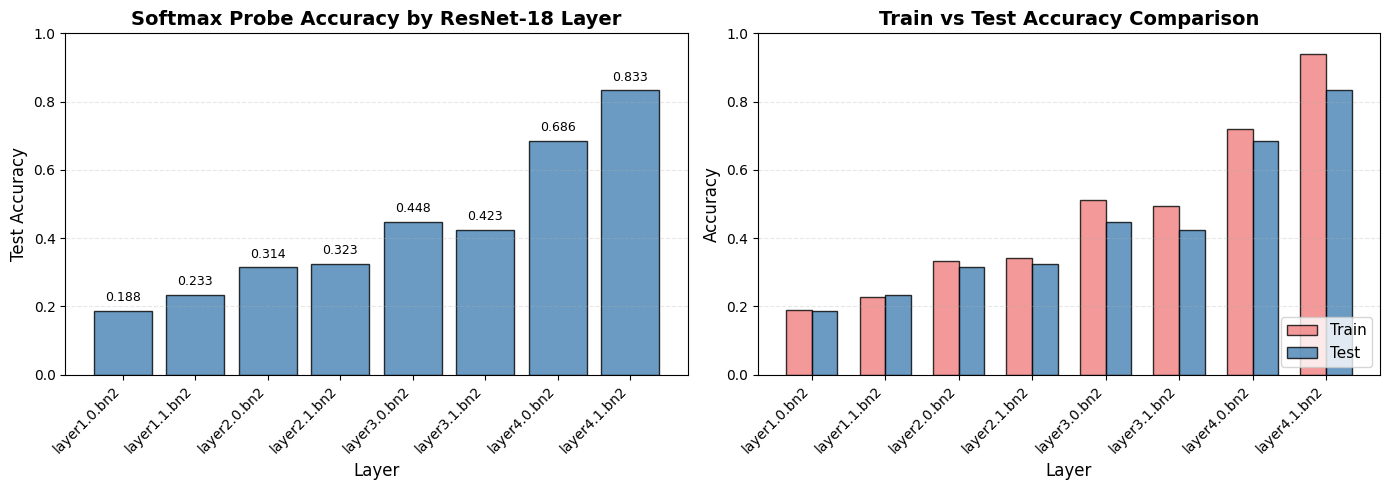


Key Observations:
Best performing layer: layer4.1.bn2 with 0.8328 test accuracy
Feature dimensionality range: 64 - 512 dimensions
Average test accuracy: 0.4311


In [ ]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Extract data for plotting
layer_names = list(layer_results.keys())
test_accuracies = [layer_results[layer]['test_acc'] for layer in layer_names]
train_accuracies = [layer_results[layer]['train_acc'] for layer in layer_names]
num_features = [layer_results[layer]['num_features'] for layer in layer_names]

# Plot 1: Test accuracy across layers
x_pos = np.arange(len(layer_names))
ax1.bar(x_pos, test_accuracies, color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Layer', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Softmax Probe Accuracy by ResNet-18 Layer', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(layer_names, rotation=45, ha='right')
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, v in enumerate(test_accuracies):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Train vs Test accuracy
x_pos = np.arange(len(layer_names))
width = 0.35
ax2.bar(x_pos - width/2, train_accuracies, width, label='Train', color='lightcoral', alpha=0.8, edgecolor='black')
ax2.bar(x_pos + width/2, test_accuracies, width, label='Test', color='steelblue', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Layer', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Train vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(layer_names, rotation=45, ha='right')
ax2.set_ylim([0, 1.0])
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nKey Observations:")
print("="*60)
best_layer = max(layer_results.items(), key=lambda x: x[1]['test_acc'])
print(f"Best performing layer: {best_layer[0]} with {best_layer[1]['test_acc']:.4f} test accuracy")
print(f"Feature dimensionality range: {min(num_features)} - {max(num_features)} dimensions")
print(f"Average test accuracy: {np.mean(test_accuracies):.4f}")

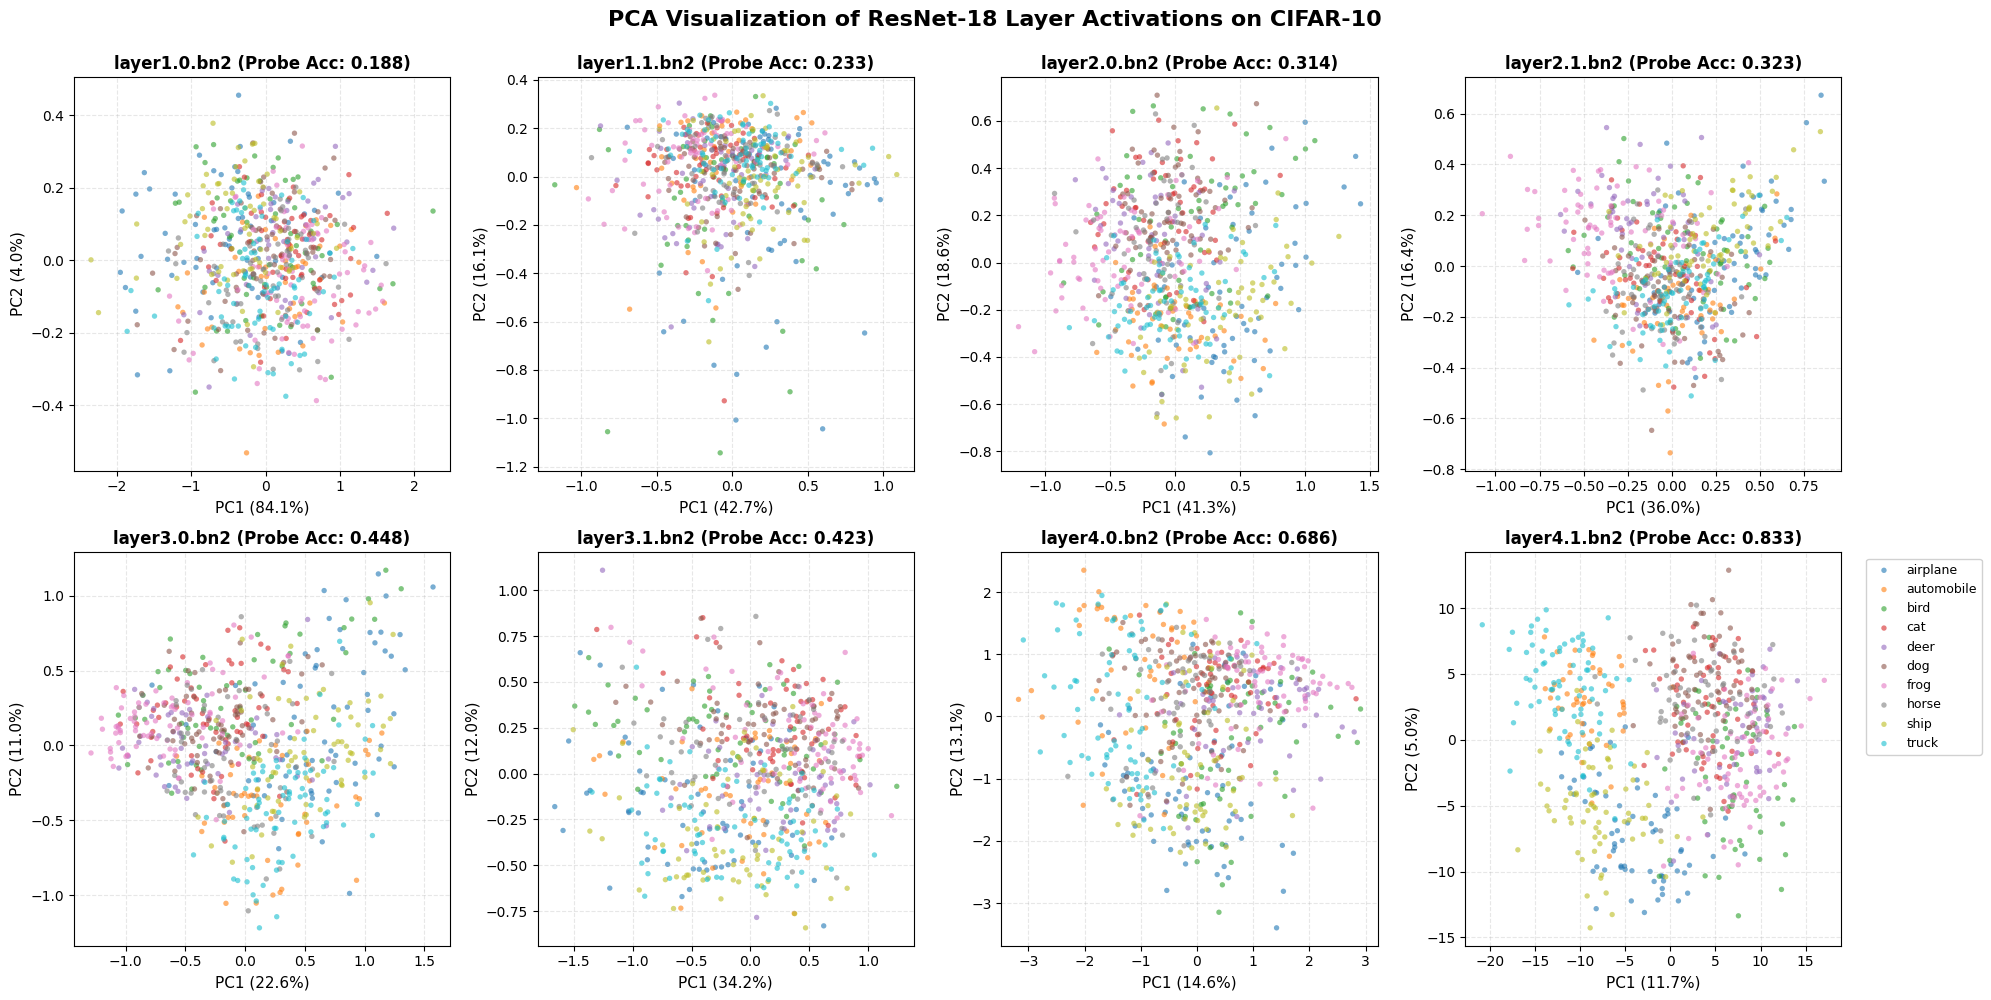

In [ ]:
# Create figure with grid for PCA plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
colors = plt.cm.tab10(np.arange(10))

# Show PCA for all 8 layers
for idx, layer_name in enumerate(layers_to_cache):
    ax = axes[idx]

    # Get test activations for this layer
    X_test = test_cached_activations[layer_name].numpy()
    y_test = test_cached_labels.numpy()

    # Apply PCA to reduce to 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_test)

    # Plot each class with different color
    for class_idx in range(10):
        mask = y_test == class_idx
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                  c=[colors[class_idx]],
                  label=class_names[class_idx],
                  alpha=0.6, s=15, edgecolors='none')

    # Format plot
    variance_explained = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({variance_explained[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({variance_explained[1]:.1%})', fontsize=11)
    ax.set_title(f'{layer_name} (Probe Acc: {layer_results[layer_name]["test_acc"]:.3f})',
                fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')

    # Add legend to last plot
    if idx == len(layers_to_cache) - 1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9,
                 framealpha=0.9, ncol=1)

plt.suptitle('PCA Visualization of ResNet-18 Layer Activations on CIFAR-10',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


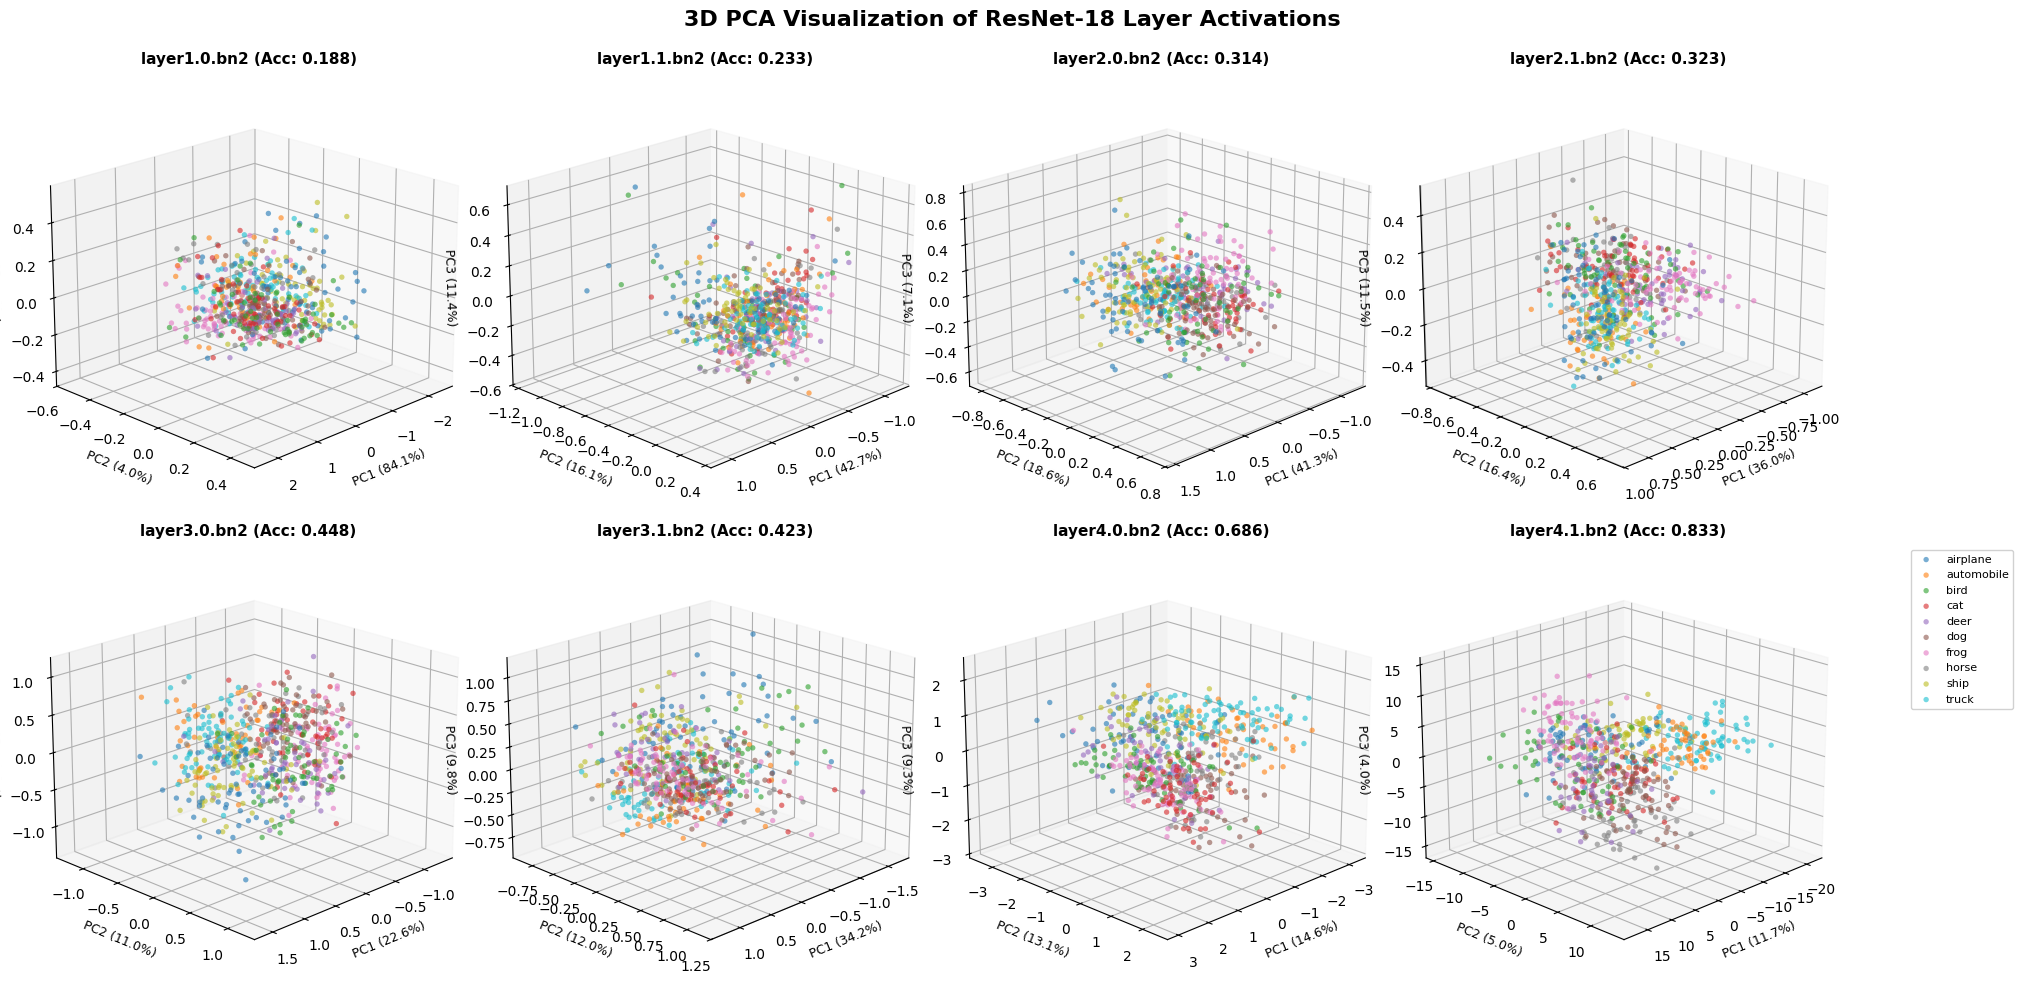

In [ ]:
# ============================================================
# 3D PCA Visualization
# ============================================================
fig = plt.figure(figsize=(20, 10))

# Show 3D PCA for all 8 layers
for idx, layer_name in enumerate(layers_to_cache):
    ax = fig.add_subplot(2, 4, idx + 1, projection='3d')

    # Get test activations for this layer
    X_test = test_cached_activations[layer_name].numpy()
    y_test = test_cached_labels.numpy()

    # Apply PCA to reduce to 3D
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_test)

    # Plot each class with different color
    for class_idx in range(10):
        mask = y_test == class_idx
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                  c=[colors[class_idx]],
                  label=class_names[class_idx],
                  alpha=0.6, s=15, edgecolors='none')

    # Format plot
    variance_explained = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({variance_explained[0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({variance_explained[1]:.1%})', fontsize=9)
    ax.set_zlabel(f'PC3 ({variance_explained[2]:.1%})', fontsize=9)
    ax.set_title(f'{layer_name} (Acc: {layer_results[layer_name]["test_acc"]:.3f})',
                fontsize=11, fontweight='bold')

    # Set viewing angle for better visualization
    ax.view_init(elev=20, azim=45)

    # Add legend to last plot
    if idx == len(layers_to_cache) - 1:
        ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=8,
                 framealpha=0.9, ncol=1)

plt.suptitle('3D PCA Visualization of ResNet-18 Layer Activations',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
# Plotly-compatible colors
plotly_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# ============================================================
# 3D PCA Visualization
# ============================================================
# Create specs for 3D subplots
specs = [[{'type': 'scatter3d'} for _ in range(4)] for _ in range(2)]

fig_3d = make_subplots(
    rows=2, cols=4,
    subplot_titles=[f'{layer} (Acc: {layer_results[layer]["test_acc"]:.3f})'
                    for layer in layers_to_cache],
    specs=specs,
    horizontal_spacing=0.03,
    vertical_spacing=0.10
)

for idx, layer_name in enumerate(layers_to_cache):
    row = idx // 4 + 1
    col = idx % 4 + 1

    # Get test activations for this layer
    X_test = test_cached_activations[layer_name].numpy()
    y_test = test_cached_labels.numpy()

    # Apply PCA to reduce to 3D
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_test)
    variance_explained = pca.explained_variance_ratio_

    # Plot each class with different color
    for class_idx in range(10):
        mask = y_test == class_idx

        fig_3d.add_trace(
            go.Scatter3d(
                x=X_pca[mask, 0],
                y=X_pca[mask, 1],
                z=X_pca[mask, 2],
                mode='markers',
                name=class_names[class_idx],
                marker=dict(
                    size=3,
                    color=plotly_colors[class_idx],
                    opacity=0.6
                ),
                legendgroup=class_names[class_idx],
                showlegend=(idx == 0),  # Only show legend for first subplot
                hovertemplate=f'{class_names[class_idx]}<br>PC1: %{{x:.2f}}<br>PC2: %{{y:.2f}}<br>PC3: %{{z:.2f}}<extra></extra>'
            ),
            row=row, col=col
        )

    # Update 3D scene with axis labels
    scene_name = 'scene' if idx == 0 else f'scene{idx + 1}'
    fig_3d.update_layout({
        scene_name: dict(
            xaxis_title=f'PC1 ({variance_explained[0]:.1%})',
            yaxis_title=f'PC2 ({variance_explained[1]:.1%})',
            zaxis_title=f'PC3 ({variance_explained[2]:.1%})',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
        )
    })

fig_3d.update_layout(
    title_text='3D PCA Visualization of ResNet-18 Layer Activations (Interactive - Click and Drag to Rotate)',
    height=800,
    width=1600,
    showlegend=True,
    hovermode='closest'
)

fig_3d.show()

## Section 5: Practical Example - Activation Visualization

Let's visualize the activations from different layers to understand what the network is learning.

In [ ]:
# Define class to collect hook values
class SaveOutput:
    def __init__(self):
        self.outputs = []

    def __call__(self, module, module_in, module_out):
        self.outputs.append(module_out)

    def clear(self):
        self.outputs = []


save_output = SaveOutput()

hook_handles = []
for layer in resnet.modules():
    # Register all hooks for Conv2d layers
    if isinstance(layer, torch.nn.modules.conv.Conv2d):
        handle = layer.register_forward_hook(save_output)
        hook_handles.append(handle)

After calling hook: 20


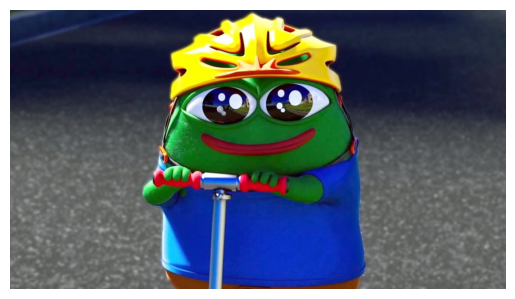

In [ ]:
PATH = "/content/peepo.jpg"

image = Image.open(PATH)
plt.imshow(image)
plt.axis('off')
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
X = transform(image).unsqueeze(dim=0).to(device)

_ = resnet(X)

print("After calling hook:", len(save_output.outputs))

# Remove hooks
for h in hook_handles:
    h.remove()

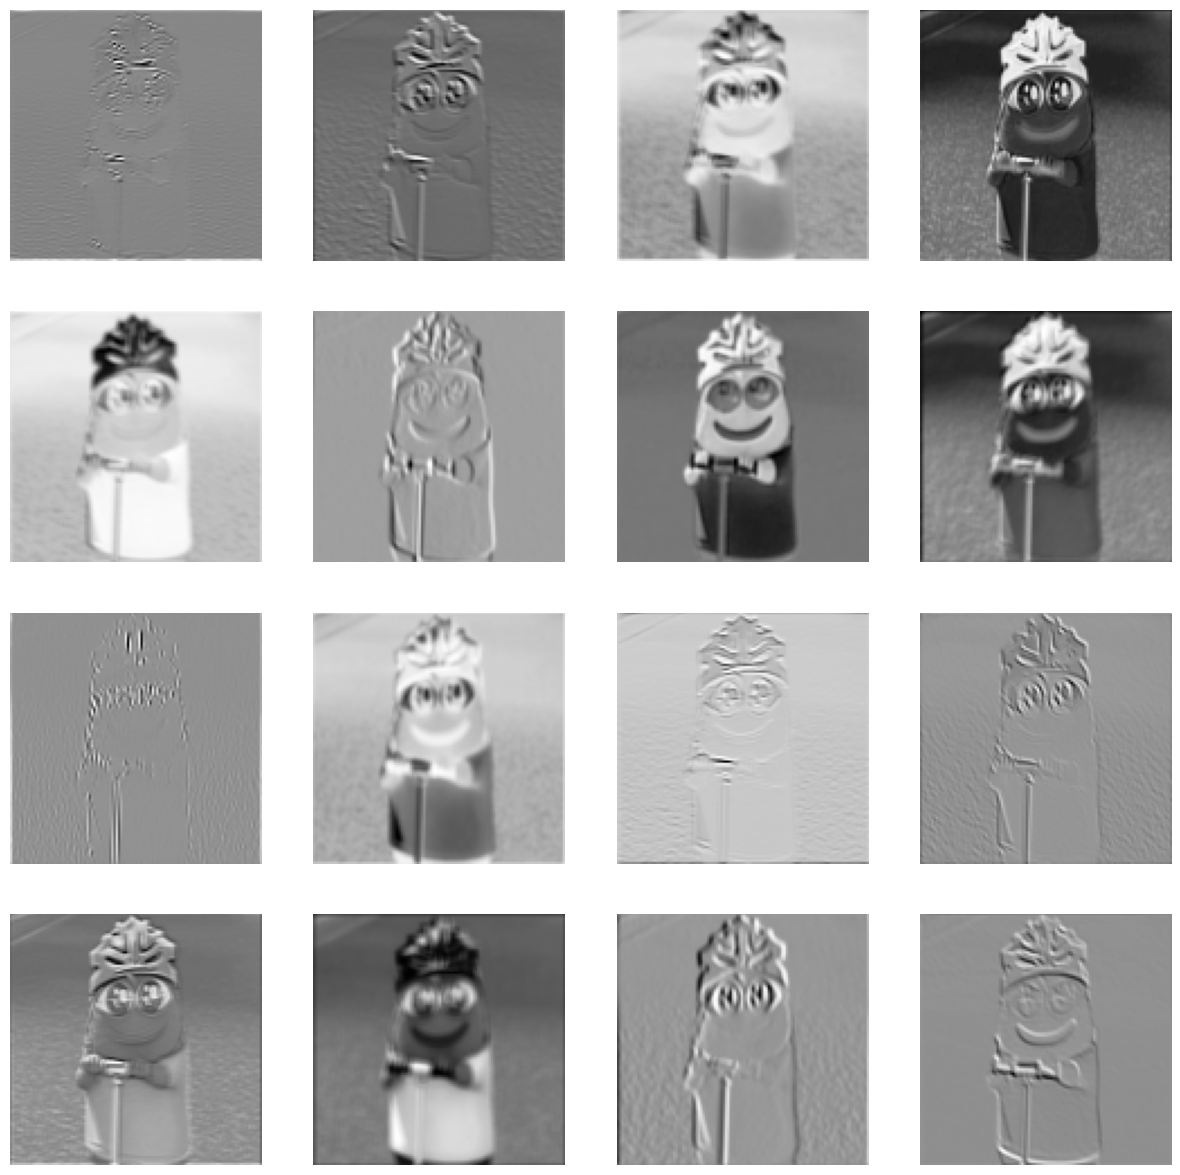

In [ ]:
# Visualize inputs to individual layers
images = save_output.outputs[0].detach().to('cpu').numpy()

with plt.style.context("seaborn-v0_8-white"):
    plt.figure(figsize=(15, 15), frameon=False)
    for idx in range(16):
        plt.subplot(4, 4, idx+1)
        plt.imshow(images[0, idx])
        plt.axis('off');

### Additional Resources

- [PyTorch Documentation on Hooks](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook)
- [Annalena Kofler Pytorch Hooks Tutorial](https://github.com/annalena-k/tutorial-pytorch-hooks)